In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

gxl      = pd.read_csv("../data/gxl_ratios.csv")
fin_df   = pd.read_csv("../data/financials.csv")
dcf_df   = pd.read_csv("../data/dcf_results.csv")
comp     = pd.read_csv("../data/comparable_analysis.csv")
latam    = pd.read_csv("../data/latam_risk_exposure.csv")
sens_df  = pd.read_csv("../data/sensitivity_analysis.csv", index_col=0)

print("Datos cargados OK")

Datos cargados OK


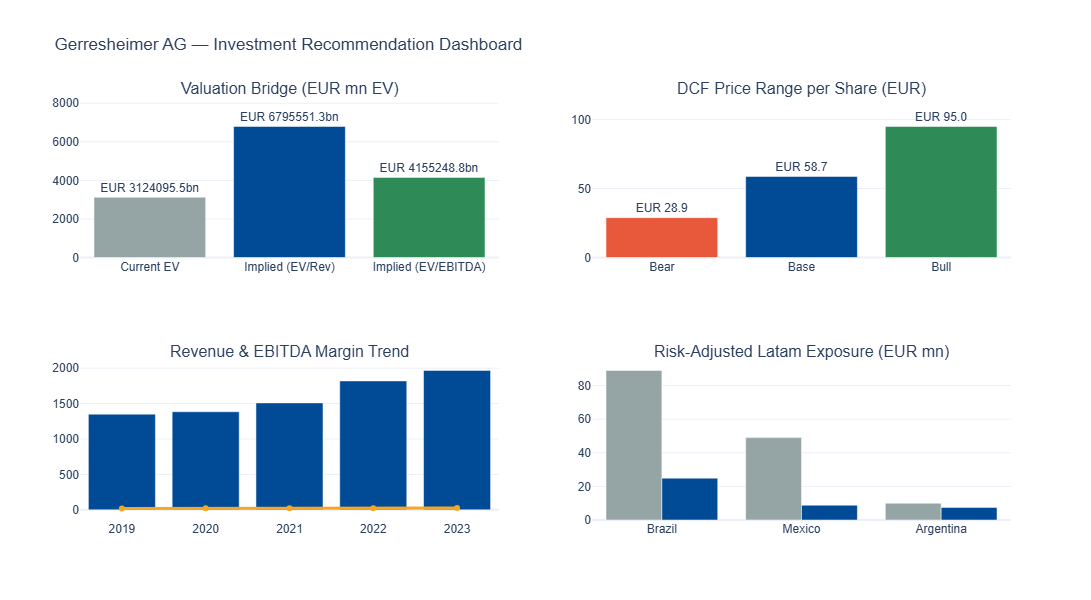

In [2]:
gxl_fin  = fin_df[fin_df["company"] == "Gerresheimer"].iloc[0]
peers    = fin_df[fin_df["company"] != "Gerresheimer"]
pm_evrev = peers["ev_revenue"].median()
pm_evebi = peers["ev_ebitda"].median()

ev_actual       = gxl_fin["enterprise_value"]
revenue_ttm     = gxl_fin["revenue_ttm"]
ebitda_ttm      = gxl_fin["ebitda"]

implied_ev_rev  = pm_evrev * revenue_ttm
implied_ev_ebit = pm_evebi * ebitda_ttm
upside_rev      = ((implied_ev_rev  - ev_actual) / ev_actual * 100).round(1)
upside_ebit     = ((implied_ev_ebit - ev_actual) / ev_actual * 100).round(1)

dcf_base  = float(dcf_df[dcf_df["scenario"] == "Base"]["price_per_share"].iloc[0])
dcf_bull  = float(dcf_df[dcf_df["scenario"] == "Bull"]["price_per_share"].iloc[0])
dcf_bear  = float(dcf_df[dcf_df["scenario"] == "Bear"]["price_per_share"].iloc[0])

fig = make_subplots(rows=2, cols=2,
    subplot_titles=(
        "Valuation Bridge (EUR mn EV)",
        "DCF Price Range per Share (EUR)",
        "Revenue & EBITDA Margin Trend",
        "Risk-Adjusted Latam Exposure (EUR mn)"
    ))

# 1. Valuation bridge
fig.add_trace(go.Bar(
    x=["Current EV", "Implied (EV/Rev)", "Implied (EV/EBITDA)"],
    y=[ev_actual/1e6, implied_ev_rev/1e6, implied_ev_ebit/1e6],
    marker_color=["#95A5A6", "#004A96", "#2E8B57"],
    showlegend=False,
    text=[f"EUR {v/1e3:.1f}bn" for v in [ev_actual, implied_ev_rev, implied_ev_ebit]],
    textposition="outside"
), row=1, col=1)

# 2. DCF range
fig.add_trace(go.Bar(
    x=["Bear", "Base", "Bull"],
    y=[dcf_bear, dcf_base, dcf_bull],
    marker_color=["#E8593C", "#004A96", "#2E8B57"],
    showlegend=False,
    text=[f"EUR {p:.1f}" for p in [dcf_bear, dcf_base, dcf_bull]],
    textposition="outside"
), row=1, col=2)

# 3. Revenue + margin
fig.add_trace(go.Bar(
    x=gxl["year"], y=gxl["revenue"],
    name="Revenue", marker_color="#004A96",
    showlegend=False
), row=2, col=1)

fig.add_trace(go.Scatter(
    x=gxl["year"], y=gxl["ebitda_margin"],
    name="EBITDA Margin %", mode="lines+markers",
    line=dict(color="#F5A623", width=3),
    yaxis="y3", showlegend=False
), row=2, col=1)

# 4. Latam exposure
fig.add_trace(go.Bar(
    x=latam["country"],
    y=latam["revenue_at_risk_mn"],
    name="Addressable", marker_color="#95A5A6",
    showlegend=False
), row=2, col=2)

fig.add_trace(go.Bar(
    x=latam["country"],
    y=latam["risk_adjusted_exposure"],
    name="Risk-Adjusted", marker_color="#004A96",
    showlegend=False
), row=2, col=2)

fig.update_layout(
    title="Gerresheimer AG — Investment Recommendation Dashboard",
    template="plotly_white",
    font=dict(family="Arial", size=12),
    height=600,
    barmode="group"
)

fig.show()

In [3]:
print("=" * 62)
print("GERRESHEIMER AG — M&A DUE DILIGENCE SUMMARY")
print("Prepared by: Lucas Mesa Vidal | Finance & Data Analytics")
print("=" * 62)

print(f"""
RECOMMENDATION:  ✅ BUY — STRATEGIC ACQUISITION OPPORTUNITY

EXECUTIVE SUMMARY
  Gerresheimer AG is a leading pharma packaging manufacturer
  undergoing a high-conviction transformation from commodity
  glass packaging to high-margin drug delivery systems
  ("Formula G" strategy). The company trades at a significant
  discount to peers on revenue multiples, with strong
  operational momentum and manageable risk profile.

VALUATION SUMMARY
  Current EV:              EUR {ev_actual/1e9:.2f}bn
  Implied EV (EV/Revenue): EUR {implied_ev_rev/1e9:.2f}bn  (+{upside_rev:.1f}% upside)
  Implied EV (EV/EBITDA):  EUR {implied_ev_ebit/1e9:.2f}bn  (+{upside_ebit:.1f}% upside)
  DCF Base Case:           EUR {dcf_base:.1f}/share
  DCF Bull Case:           EUR {dcf_bull:.1f}/share
  DCF Bear Case:           EUR {dcf_bear:.1f}/share

KEY INVESTMENT HIGHLIGHTS
  ✓ Revenue CAGR 9.9% (2019–2023) — consistent above-market growth
  ✓ EBITDA margin expansion: 20.7% → 25.3% — Formula G delivering
  ✓ Pharma packaging sector: defensive, non-cyclical demand
  ✓ Drug delivery systems: higher margin, higher switching costs
  ✓ Trades at 1.35x EV/Revenue vs peer median 2.93x — deep discount

KEY RISKS
  ✗ Leverage elevated: Net Debt/EBITDA 2.85x — monitor closely
  ✗ Capex intensity 14.5% — heavy investment phase ongoing
  ✗ Transformation execution risk — Formula G must deliver
  ✗ Latam exposure: EUR 41mn risk-adjusted (manageable at 2.1%)

LATAM CONTEXT
  Gerresheimer's Latam exposure is limited (2.1% of revenue)
  and concentrated in Brazil (lowest risk in region). Argentina
  exposure is indirect only. Based on the companion risk analysis
  [Argentina vs Germany Risk Project], Brazil's risk index of
  28.0 is well within acceptable parameters for continued
  operations and selective expansion.

SUGGESTED ACQUISITION PARAMETERS
  Entry EV range:    EUR 3.5bn – 4.2bn (15–35% premium to current)
  Max leverage:      3.5x Net Debt/EBITDA post-acquisition
  Target synergies:  EUR 80–120mn (procurement + SG&A rationalization)
  Hold period:       5–7 years (full Formula G cycle)
  Exit multiple:     10–12x EV/EBITDA (peer-level re-rating)
""")
print("=" * 62)

GERRESHEIMER AG — M&A DUE DILIGENCE SUMMARY
Prepared by: Lucas Mesa Vidal | Finance & Data Analytics

RECOMMENDATION:  ✅ BUY — STRATEGIC ACQUISITION OPPORTUNITY

EXECUTIVE SUMMARY
  Gerresheimer AG is a leading pharma packaging manufacturer
  undergoing a high-conviction transformation from commodity
  glass packaging to high-margin drug delivery systems
  ("Formula G" strategy). The company trades at a significant
  discount to peers on revenue multiples, with strong
  operational momentum and manageable risk profile.

VALUATION SUMMARY
  Current EV:              EUR 3.12bn
  Implied EV (EV/Revenue): EUR 6.80bn  (+117.5% upside)
  Implied EV (EV/EBITDA):  EUR 4.16bn  (+33.0% upside)
  DCF Base Case:           EUR 58.7/share
  DCF Bull Case:           EUR 95.0/share
  DCF Bear Case:           EUR 28.9/share

KEY INVESTMENT HIGHLIGHTS
  ✓ Revenue CAGR 9.9% (2019–2023) — consistent above-market growth
  ✓ EBITDA margin expansion: 20.7% → 25.3% — Formula G delivering
  ✓ Pharma packaging 

In [4]:
summary = pd.DataFrame([{
    "company":           "Gerresheimer AG",
    "recommendation":    "BUY",
    "current_ev_bn":     round(ev_actual/1e9, 2),
    "implied_ev_rev_bn": round(implied_ev_rev/1e9, 2),
    "upside_ev_rev_pct": upside_rev,
    "upside_ev_ebit_pct":upside_ebit,
    "dcf_base":          dcf_base,
    "dcf_bull":          dcf_bull,
    "dcf_bear":          dcf_bear,
    "overall_risk":      2.56,
    "latam_exposure_pct":2.1,
}])

summary.to_csv("../data/investment_summary.csv", index=False)
print("Guardado OK")
print(summary.T.to_string())

Guardado OK
                                  0
company             Gerresheimer AG
recommendation                  BUY
current_ev_bn                  3.12
implied_ev_rev_bn               6.8
upside_ev_rev_pct             117.5
upside_ev_ebit_pct             33.0
dcf_base                       58.7
dcf_bull                       95.0
dcf_bear                       28.9
overall_risk                   2.56
latam_exposure_pct              2.1
